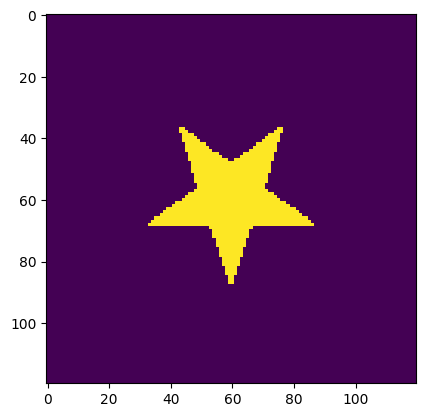

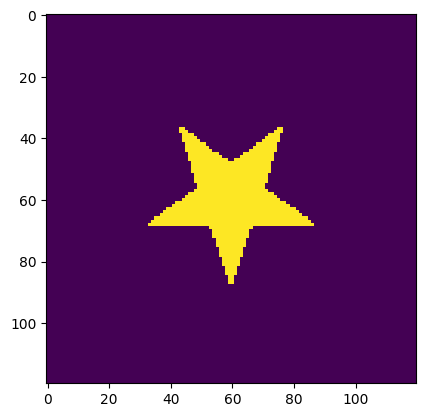

0.8811914560331726


In [1]:
import sys
sys.path.insert(1, '../../eispy2d/library/')
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

import configuration as cfg
import inputdata as ipt
import result as rst
import draw
import mom_cg_fft as mom

# Parameters
name = 'test'
NM = NS = 80
Ro = 4.
lambda_b = 1.
epsilon_rb = 1.
Lx = Ly = 2.
E0 = 1.
perfect_dielectric = True
resolution = (120, 120)
noise = 5.
indicators = [rst.SHAPE_ERROR, rst.POSITION_ERROR]
epsilon_rd = 1.25
l = 0.5
position1 = [.0, .0]

position2 = [.5, .5]

star1, _ = draw.star5(
    l, axis_length_x=Lx, axis_length_y=Ly, resolution=resolution,
    background_rel_permittivity=epsilon_rb, object_rel_permittivity=epsilon_rd,
    center=position1, rotate=0.
)

star2, _ = draw.star5(
    l, axis_length_x=Lx, axis_length_y=Ly, resolution=resolution,
    background_rel_permittivity=epsilon_rb, object_rel_permittivity=epsilon_rd*5,
    center=position1, rotate=0.
)

plt.imshow(star1)
plt.show()

plt.imshow(star2)
plt.show()

data_range1 = star1.max() - star1.min()
data_range2 = star2.max() - star2.min()
if data_range1 > data_range2:
    data_range = data_range1
else:
    data_range = data_range2
ssim_index = ssim(star1, star2, data_range=data_range)
print(ssim_index)

O erro de posição afeta significativamente. O erro de estimativa afeta, mas nem tanto. Ou seja, para comparar com o indicador de posição, bastaria eu mostrar que a dificuldade em recuperar a geometria afetaria na mensuração da capacidade de localização.



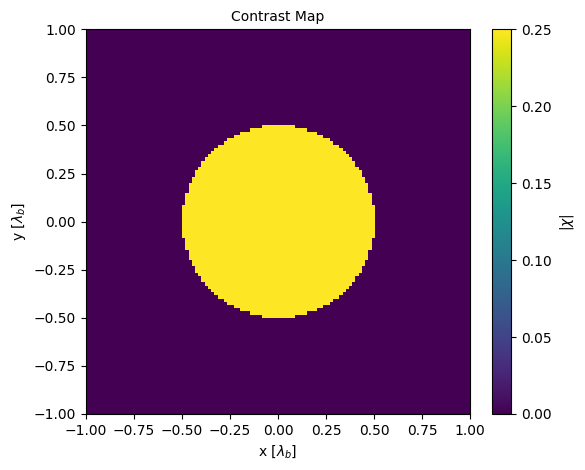

In [2]:
import analytical as ana

name = 'test'
NM = NS = 80
Ro = 4.
lambda_b = 1.
epsilon_rb = 1.
Lx = Ly = 2.
E0 = 1.
perfect_dielectric = True
resolution = (120, 120)
noise = 5.
indicators = [rst.SHAPE_ERROR, rst.POSITION_ERROR, rst.SSIM_ERROR, 
              rst.REL_PERMITTIVITY_PAD_ERROR]
epsilon_rd = 1.25
contrast = (epsilon_rd-epsilon_rb)/epsilon_rb
l = 0.5
position = [.0, .0]

config = cfg.Configuration(name=name + '.cfg', number_measurements=NM, 
                           number_sources=NS, observation_radius=Ro, 
                           wavelength=lambda_b,
                           background_permittivity=epsilon_rb,
                           image_size=[Ly, Lx], magnitude=E0,
                           perfect_dielectric=perfect_dielectric)


test = ipt.InputData(name=name + '.ipt', configuration=config, 
                     resolution=resolution, noise=noise, indicators=indicators)

forward = ana.Analytical(contrast=contrast, radius=l, position=position)
_ = forward.solve(test)

test.draw(show=True)

In [3]:
import circleapproximation as ca
import stochastic as stc
import richmond as ric

contrast_range = [0., 5.]

discretization = ric.Richmond(configuration=test.configuration,
                              elements=resolution)

method = ca.CircleApproximation(stc.OutputMode(stc.BEST_CASE, reference='ssim'),
                           number_executions=1,
                           contrast_range=contrast_range,
                           solver="de")

result = method.solve(test, discretization, print_info=True)

Method: 
Alias: ca
Input Data: test.ipt
Discretization: Richmond Method (120x120)
Parallelization: False
Number of executions: 1
Output rule: best, reference: ssim, sample rate: 5.0 %
Position range: None
Radius range: None
Contrast range: [0.0, 5.0]
--------------------------------------------------
Execution: 0
Iteration: 1 - f(x): 73.01478625673744
Iteration: 2 - f(x): 73.01478625673744
Iteration: 3 - f(x): 70.87765918856128
Iteration: 4 - f(x): 70.87765918856128
Iteration: 5 - f(x): 46.691336204025816
Iteration: 6 - f(x): 46.691336204025816
Iteration: 7 - f(x): 46.691336204025816
Iteration: 8 - f(x): 46.691336204025816
Iteration: 9 - f(x): 46.691336204025816
Iteration: 10 - f(x): 46.691336204025816
Iteration: 11 - f(x): 39.00454250143166
Iteration: 12 - f(x): 38.186982734311975
Iteration: 13 - f(x): 27.140240147874096
Iteration: 14 - f(x): 27.140240147874096
Iteration: 15 - f(x): 27.140240147874096
Iteration: 16 - f(x): 15.57952672446958
Iteration: 17 - f(x): 10.719176259768991
Ite

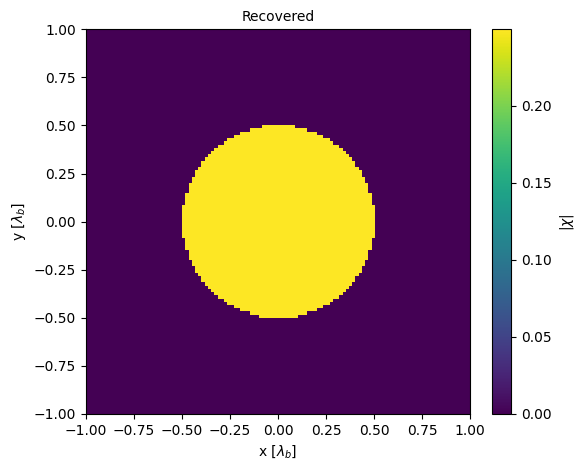

In [4]:
result.plot_map(show=True)

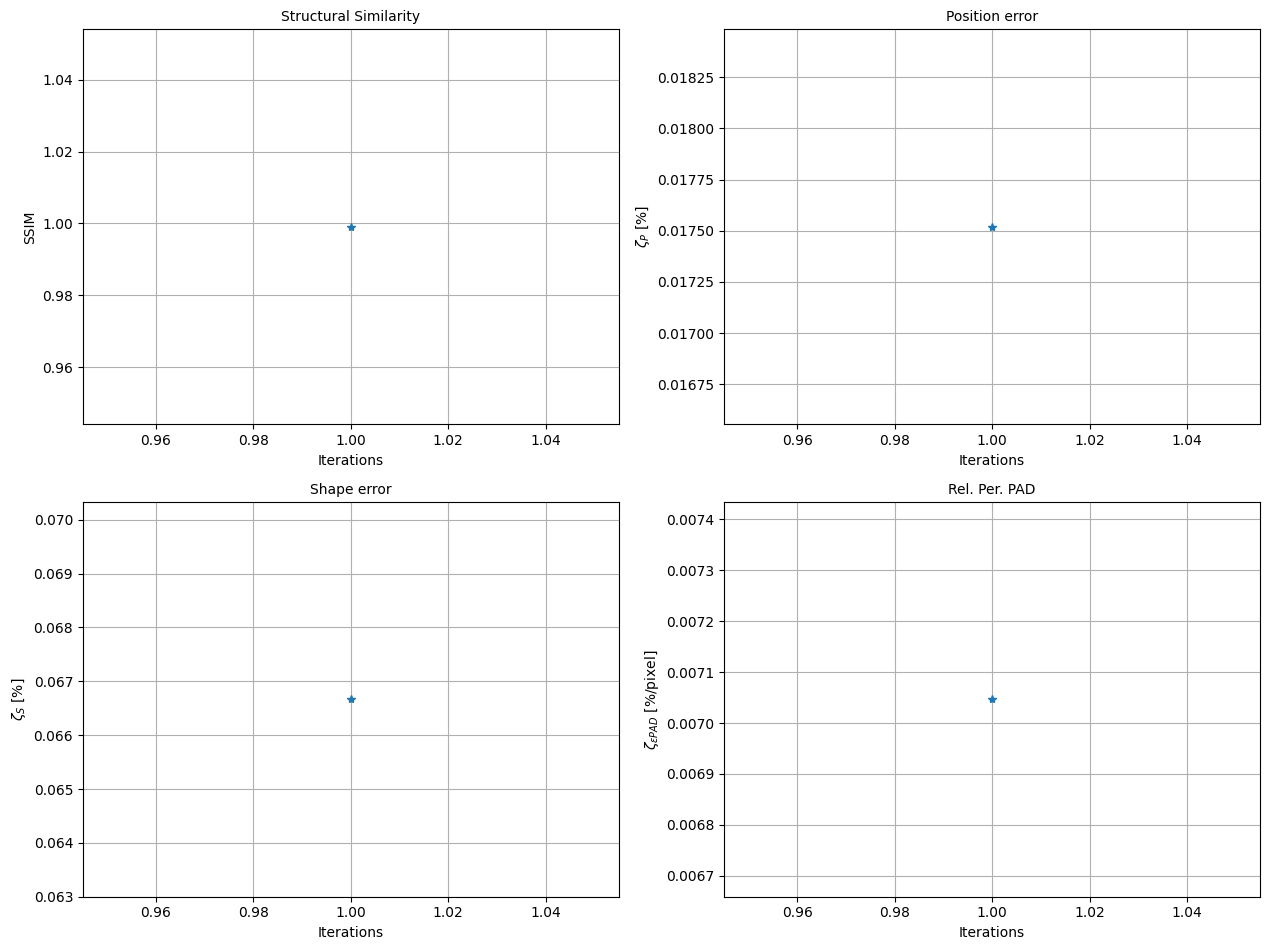

(<Figure size 1280x960 with 4 Axes>,
 array([<Axes: title={'center': 'Structural Similarity'}, xlabel='Iterations', ylabel='SSIM'>,
        <Axes: title={'center': 'Position error'}, xlabel='Iterations', ylabel='$\\zeta_{P}$ [%]'>,
        <Axes: title={'center': 'Shape error'}, xlabel='Iterations', ylabel='$\\zeta_{S}$ [%]'>,
        <Axes: title={'center': 'Rel. Per. PAD'}, xlabel='Iterations', ylabel='$\\zeta_{\\epsilon PAD}$ [%/pixel]'>],
       dtype=object))

In [5]:
result.plot_convergence(indicators=['ssim', 'zeta_p', 'zeta_s', 'zeta_epad'],
                        show=True)

In [4]:
import stopcriteria as stp
import richmond as ric
import csi

recover_resolution = (60, 60)

method = csi.ContrastSourceInversion(stp.StopCriteria(max_iterations=100))

discretization = ric.Richmond(configuration=test.configuration,
                              elements=recover_resolution)

result = method.solve(test, discretization, print_info=True)

Method: Contrast Source Inversion
Alias: csi
Input Data: test.ipt
Discretization: Richmond Method (60x60)
Method of Moments - CG-FFT (iterations=5000, tolerance=1.0e-03)
Stop Criteria
Maximum number of iterations: 100
Iteration: 1 -  Rel. Per. PAD: 5.25%, Shape: 22.53, Position: 0.03,
Iteration: 2 -  Rel. Per. PAD: 5.24%, Shape: 22.40, Position: 0.00,
Iteration: 3 -  Rel. Per. PAD: 5.24%, Shape: 22.40, Position: 0.00,
Iteration: 4 -  Rel. Per. PAD: 5.24%, Shape: 22.27, Position: 0.03,
Iteration: 5 -  Rel. Per. PAD: 5.23%, Shape: 21.93, Position: 0.07,
Iteration: 6 -  Rel. Per. PAD: 5.23%, Shape: 21.73, Position: 0.09,
Iteration: 7 -  Rel. Per. PAD: 5.23%, Shape: 21.73, Position: 0.09,
Iteration: 8 -  Rel. Per. PAD: 5.23%, Shape: 21.60, Position: 0.07,
Iteration: 9 -  Rel. Per. PAD: 5.22%, Shape: 21.13, Position: 0.03,
Iteration: 10 -  Rel. Per. PAD: 5.22%, Shape: 20.67, Position: 0.03,
Iteration: 20 -  Rel. Per. PAD: 5.19%, Shape: 20.00, Position: 0.00,
Iteration: 30 -  Rel. Per. PAD: 

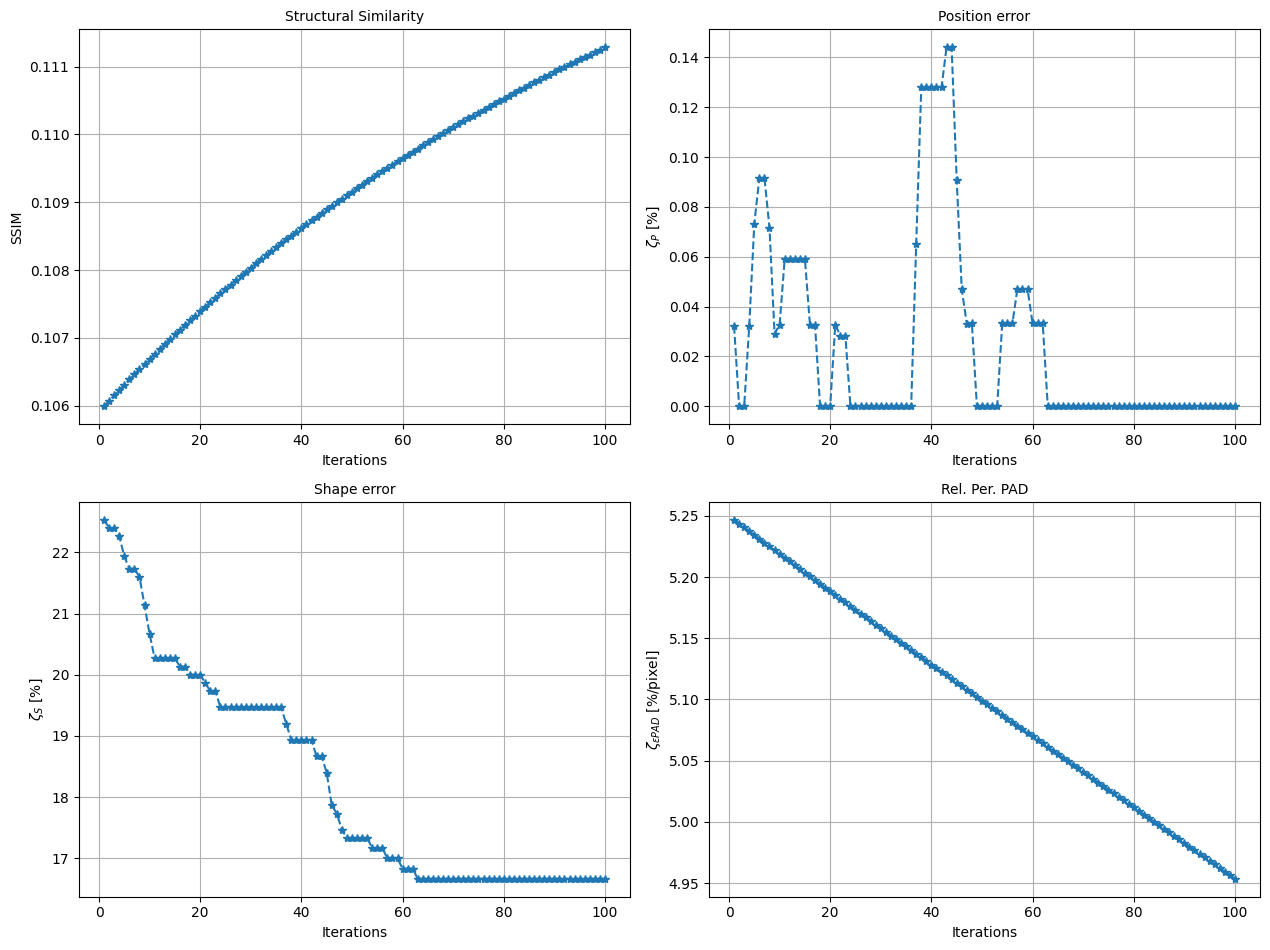

(<Figure size 1280x960 with 4 Axes>,
 array([<Axes: title={'center': 'Structural Similarity'}, xlabel='Iterations', ylabel='SSIM'>,
        <Axes: title={'center': 'Position error'}, xlabel='Iterations', ylabel='$\\zeta_{P}$ [%]'>,
        <Axes: title={'center': 'Shape error'}, xlabel='Iterations', ylabel='$\\zeta_{S}$ [%]'>,
        <Axes: title={'center': 'Rel. Per. PAD'}, xlabel='Iterations', ylabel='$\\zeta_{\\epsilon PAD}$ [%/pixel]'>],
       dtype=object))

In [5]:
result.plot_convergence(indicators=['ssim', 'zeta_p', 'zeta_s', 'zeta_epad'],
                        show=True)